In [13]:
"""
1.sales_2015.xlsx 파일의  january_2015 sheet의 중
 열이  "Customer Name", "Sale Amount" 컬럼만 
 sales_2015_amt.xlsx 파일로 저장하기  
"""
import pandas as pd

infile="sales_2015.xlsx"
outfile = "sales_2015_amt.xlsx"
df = pd.read_excel(infile,"january_2015",index_col=None)
df_value = df.loc[:,["Customer Name","Sale Amount"]]
writer = pd.ExcelWriter(outfile)
df_value.to_excel(writer,sheet_name="january_2015",index=False)
writer.close()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [14]:


"""
2. supplier_data.csv 파일을 
   pandas를 이용하여 읽고 Purchase Date 컬럼의 값이 1/20/14인 데이터만 
   140120_data.csv 파일로 저장하기
"""
import pandas as pd

infile = "supplier_data.csv"
df = pd.read_csv(infile)
print(df);

df_inset = df.loc[df["Purchase Date"] == "1/20/14"]
print(df_inset)
df_inset.to_csv("140120_data.csv",index=False)

   Supplier Name Invoice Number  Part Number     Cost Purchase Date
0     Supplier X       001-1001         2341  $500.00       1/20/14
1     Supplier X       001-1001         2341  $500.00       1/20/14
2     Supplier X       001-1001         5467  $750.00       1/20/14
3     Supplier X       001-1001         5467  $750.00       1/20/14
4     Supplier Y        50-9501         7009  $250.00       1/30/14
5     Supplier Y        50-9501         7009  $250.00       1/30/14
6     Supplier Y        50-9505         6650  $125.00        2/3/14
7     Supplier Y        50-9505         6650  $125.00        2/3/14
8     Supplier Z       920-4803         3321  $615.00        2/3/14
9     Supplier Z       920-4804         3321  $615.00       2/10/14
10    Supplier Z       920-4805         3321  $615.00       2/17/14
11    Supplier Z       920-4806         3321  $615.00       2/24/14
  Supplier Name Invoice Number  Part Number     Cost Purchase Date
0    Supplier X       001-1001         2341  $500

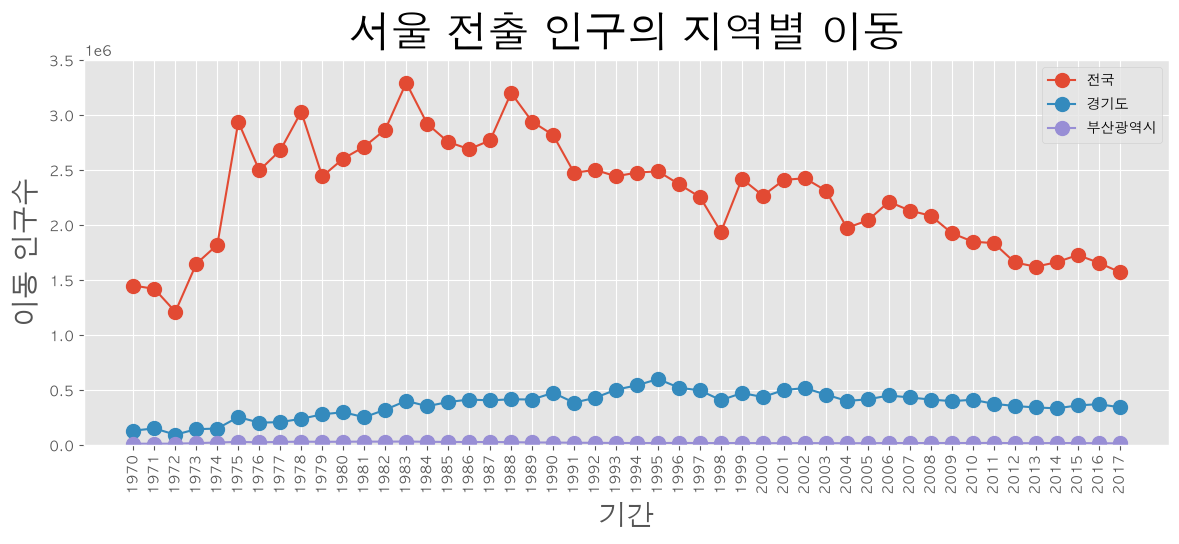

In [6]:

'''
 3. 시도별 전출입 인구수.xlsx 파일을 읽어 다음 그래프를 작성하기
    전출지가 서울특별시이고 전입지가 "전국","경기도","부산광역시" 데이터를 
    읽어 그래프로 출력하기
''' 
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("시도별 전출입 인구수.xlsx")
# NA인 경우 앞의 값으로 채우기 
df = df.ffill()
#서울시에서 다른지역으로 이주한 정보 선택 : df_seoul 저장 
mask=(df["전출지별"] == '서울특별시') & (df["전입지별"] != '서울특별시')
df_seoul = df[mask]

#전출지별 컬럼 삭제. 모두 서울특별시값이므로 제거.
df_seoul = df_seoul.drop("전출지별",axis=1)
#전입지별 컬럼명 => 전입지 변경 
df_seoul.rename(columns={'전입지별':'전입지'}, inplace=True)
# 전입지 컬럼을 인덱스명으로 설정. 
df_seoul.set_index('전입지', inplace=True)

#한글 폰트 
from matplotlib import  rc
rc('font', family="AppleGothic") #현재 폰트 변경 설정. 한글사용가능한 폰트
sr2 = df_seoul.loc[["전국","경기도","부산광역시"]]
sr3=sr2.T #전치행렬. 행과 열을 바꾼 행렬
plt.style.use('ggplot') # 스타일 서식 지정
plt.figure(figsize=(14, 5)) #크기 지정
plt.xticks(size=10, rotation='vertical') #x축 레이블을 세로로 표시 
# x, y축 데이터를 plot 함수에 입력 
plt.plot(sr3, marker='o', markersize=10)  # 마커 표시 추가
plt.title('서울 전출 인구의 지역별 이동', size=30)  #차트 제목
plt.xlabel('기간', size=20)                  #x축 이름
plt.ylabel('이동 인구수', size=20)           #y축 이름
plt.ylim(0, 3500000)
plt.legend(sr3.columns) #범례 표시
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Text(0.5, 1.0, 'Sales Amount')

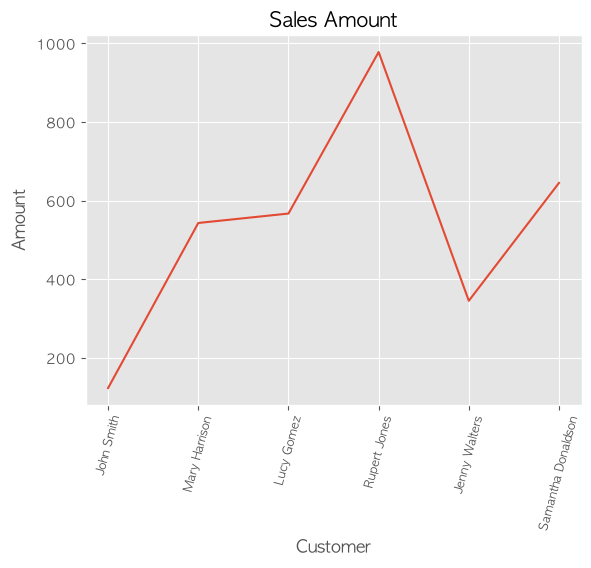

In [11]:

'''
  4. sales_2015.xlsx 파일의 january_2015 sheet 을 읽어 
    Customer Name별 Sale Amount 를 선그래프로 시각화 하기
     그래프 작성하기
'''
import pandas as pd
import matplotlib.pyplot as plt

infile="sales_2015.xlsx"
df = pd.read_excel(infile,"january_2015",index_col=None)
df_value = df[["Customer Name","Sale Amount"]]
#Customer Name 컬럼을 인덱스로 변경.
df_value.set_index('Customer Name', inplace=True)
plt.style.use("ggplot")
plt.plot(df_value)
plt.xlabel("Customer")
plt.ylabel("Amount") 
plt.xticks(rotation=75,fontsize="small")
plt.title("Sales Amount")